In [2]:
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

import gropt

In [3]:
def plot_safe(g, gparams, safe_params, safe_params_cardiac, model=1):
    
    if model == 1:
        safe = gropt.gropt_wrapper.get_SAFE(g, gparams.dt, 
                                        safe_params=safe_params)
        safe_cardiac = gropt.gropt_wrapper.get_SAFE(g, gparams.dt, 
                                            safe_params=safe_params_cardiac)
    elif model == 2:
        safe = gropt.gropt_wrapper.get_SAFE2(g, gparams.dt, 
                                        safe_params=safe_params)
        safe_cardiac = gropt.gropt_wrapper.get_SAFE2(g, gparams.dt, 
                                            safe_params=safe_params_cardiac)
        
    print(f'Max SAFE {np.max(safe):.3f}  Max SAFE Cardiac {np.max(safe_cardiac):.3f}')
    plt.figure(figsize=(6,3))
    plt.plot(safe)
    plt.plot(safe_cardiac)
    plt.show()

[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe('C:/Users/mloecher/Downloads/MP_GradSys_P034_X60.asc')

In [5]:
timings_file = '../../private_SAFEdiff/diffusion_timing_parameters_Gmax200.mat'

timings_data = loadmat(timings_file)
T_90 = timings_data['rf_90_duration'][0][0] - timings_data['rf_90_rfCenterInclDelay'][0][0] + timings_data['nav_dur'][0][0]
T_180 = timings_data['rf_180_duration'][0][0] 
sys = timings_data['sys']
dt = 1e-5
T_readout = timings_data['timeToTE'][0][0]

Final Good: True   Solve time: 289.2 ms   N: 325    feval: 8493
Final b-value: 1734 s/mm^2
Max SAFE 0.792  Max SAFE Cardiac 0.798


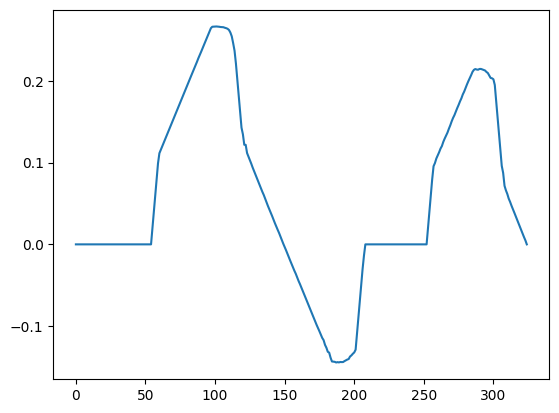

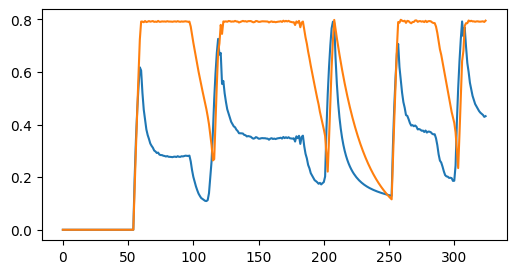

In [38]:
gparams = gropt.GroptParams()
gparams.diff_init(T_90=T_90,
                  T_180=T_180,
                  T_readout=T_readout,
                  TE = 46e-3,
                  dt = 100e-6)

gparams.add_gmax(.4)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_bvalue(1700,1, mode = 3)


gparams.add_SAFE2(0.8, safe_params=safe_params)
gparams.add_SAFE2(0.8, safe_params=safe_params_cardiac)

start_t = timer()

solver = gropt.SolverGroptSDMM()
solver.set_general_params(min_iter = 200, max_iter=10000, max_feval = 100000)
solver.solve(gparams)
out = gparams.get_out()

stop_t = timer()
print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms   N: {out.size}    feval: {gparams.final_n_feval}')
print(f'Final b-value: {gparams.get_output_bvalue():.0f} s/mm^2')

plt.figure()
plt.plot(out)

plot_safe(out, gparams, safe_params, safe_params_cardiac)